In [119]:
import numpy as np
import pandas as pd
import os
print(os.getcwd())
os.chdir("California_housing_ml_model")
print(os.getcwd())

/home/shreyas-nalle/Desktop/Data Science/Machine_learning/California_housing_ml_model


FileNotFoundError: [Errno 2] No such file or directory: 'California_housing_ml_model'

In [ ]:
df = pd.read_csv("housing.csv")
df

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.tail()

In [ ]:
df.value_counts()

In [ ]:
df["ocean_proximity"].value_counts()

In [ ]:
# values_counts gives the total number of rows which are excalty the same

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df.hist(figsize = (12, 8), bins = 50)

In [ ]:
def shuffle_and_split(data, test_ratio) :
    np.random.seed(42) # this makes sure that eveytime this function runs the randon numbers generated are alwasy the same 
    shuffled_indices = np.random.permutation(len(data)) # this returns shuffled indices
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[test_indices], data.iloc[train_indices]

In [ ]:
test, train = shuffle_and_split(df, 0.2)

In [ ]:
test

In [ ]:
train

In [120]:
df["income_cat"] = pd.cut(df["median_income"], bins = [0, 1.5, 3.0, 4.5, 6.0, np.inf], labels = [1, 2, 3, 4, 5])
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND,2
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN,5
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND,2
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN,2
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN,4
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND,2
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN,3
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN,3


Text(0, 0.5, 'NUmber of Instances')

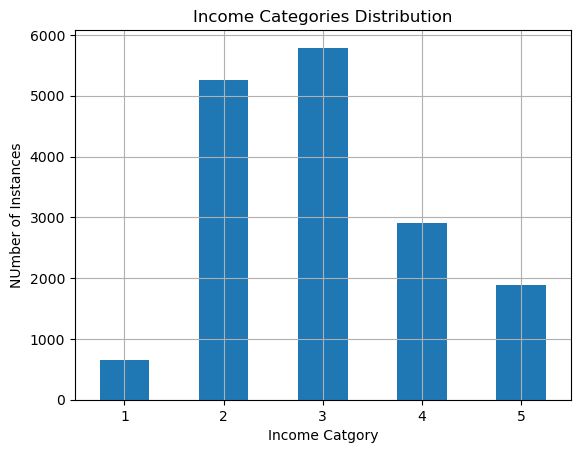

In [121]:
import matplotlib.pyplot as plt
df["income_cat"].value_counts().sort_index().plot.bar(rot = 0, grid = True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Catgory")
plt.ylabel("NUmber of Instances")

In [122]:
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
for train_index, test_index in sss.split(df, df["income_cat"]) :
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

KeyError: '[16060, 17, 6187, 16092, 3729, 1419, 11672, 13894, 10769, 9769, 4544, 10569, 8074, 5593, 4038, 1838, 13606, 4457, 5376, 13661, 2194, 13524, 4141, 8606, 6188, 5550, 1765, 11649, 12311, 12259, 11312, 8002, 15952, 12033, 15169, 16066, 5358, 6599, 12160, 10458, 16403, 12117, 9019, 2709, 9896, 116, 5397, 3092, 12665, 2130, 10767, 3509, 7176, 15741, 10582, 15491, 8573, 10871, 11265, 5988, 4881, 14704, 11425, 16182, 10267, 13837, 9802, 9823, 5617, 10674, 13097, 11423, 5094, 5784, 6928, 9908, 10834, 15190, 8516, 1662, 15443, 7683, 2569, 998, 11977, 11880, 10555, 14612, 8111, 7623, 8518, 3091, 2518, 13580, 263, 13289, 6775, 970, 761, 6619, 4262, 5985, 2349, 11670, 7516, 8789, 9282, 7468, 3518, 12432, 15684, 11603, 9920, 5072, 7342, 7094, 15030, 5591, 9349, 4396, 7100, 7326, 13436, 4144, 8931, 8993, 7916, 10486, 1636, 10336, 7207, 470, 3859, 11523, 2484, 11972, 3952, 2843, 8494, 1766, 9574, 2890, 2834, 16290, 13692, 13234, 5568, 4280, 5899, 14830, 9406, 14425, 3189, 918, 674, 4105, 91

In [123]:
print(strat_train_set)
strat_test_set["income_cat"].value_counts().sort_index().plot.bar(rot = 0)
plt.xlabel("Income Ctegory for the training set")
plt.ylabel("Number of instances for the testing set")
plt.title("Training set")

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   
...          ...       ...                 ...          ...             ...   
15174    -117.07     33.03                14.0       6665.0          1231.0   
12661    -121.42     38.51                15.0       7901.0          1422.0   
19263    -122.72     38.44                48.0        707.0           166.0   
19140    -122.70     38.31                14.0       3155.0           580.0   
19773    -122.14     39.97                27.0       1079.0           222.0   

       population  households  median_income  media

KeyError: 'income_cat'

<Axes: xlabel='longitude', ylabel='latitude'>

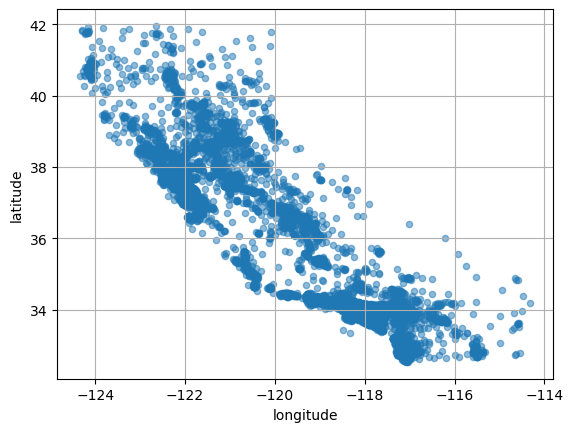

In [124]:
df.plot.scatter(x = "longitude", y = "latitude", grid = True, alpha = 0.5)

In [125]:
# let's remove the income_cat column as we have succeffuled performed stratified shuffling split
strat_train_set = strat_train_set.drop("income_cat", axis = 1)
strat_train_set

KeyError: "['income_cat'] not found in axis"

In [126]:
strat_test_set = strat_test_set.drop("income_cat", axis = 1)
strat_test_set

KeyError: "['income_cat'] not found in axis"

<Axes: xlabel='latitude', ylabel='longitude'>

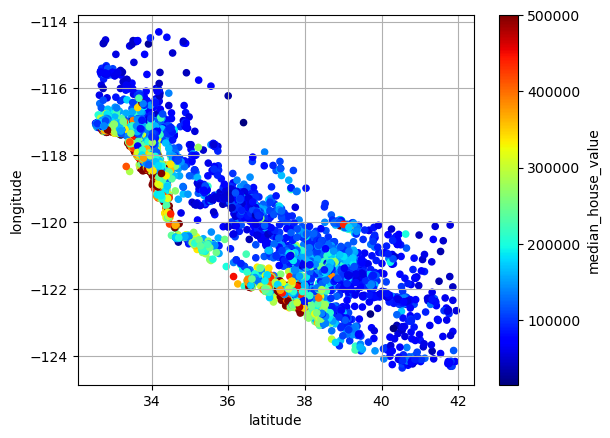

In [127]:
df.plot.scatter(x = "latitude", y = "longitude", grid = True, cmap = "jet", c = "median_house_value")

In [128]:
df.drop("ocean_proximity", axis = 1, inplace = True)
df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466,-0.016281
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673,-0.078768
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146,-0.139314
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140,0.221745
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781,0.012635
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882,0.022900
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590,0.035115
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151,0.902151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000,0.642256
income_cat,-0.016281,-0.078768,-0.139314,0.221745,0.012635,0.022900,0.035115,0.902151,0.642256,1.000000


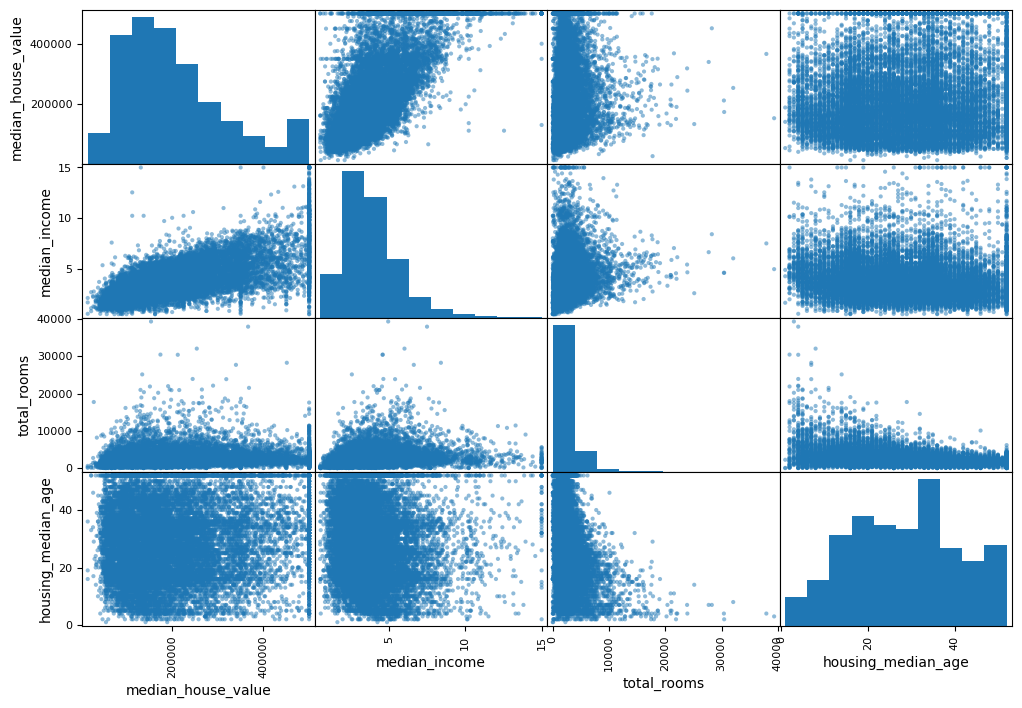

In [129]:
from pandas.plotting import scatter_matrix
attributes =["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(df[attributes], figsize = (12, 8))
plt.show()

In [130]:
df = strat_train_set.copy()
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN


In [131]:
housing = strat_train_set.drop("median_house_value", axis = 1)
housing_labels = strat_train_set["median_house_value"].copy()
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,<1H OCEAN


In [132]:
housing_labels
# we seperated the features and the label 

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
           ...   
15174    268500.0
12661     90400.0
19263    140400.0
19140    258100.0
19773     62700.0
Name: median_house_value, Length: 16512, dtype: float64

In [133]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median")
housing_num = housing.select_dtypes(include = [np.number])
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [134]:
imputer.statistics_ # so the fit only calculates the mean it dosent replace the non zero values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [135]:
x = imputer.transform(housing_num) # while the transform actually replaces the value of mean into the missing place 

In [136]:
x

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]], shape=(16512, 8))

In [137]:
housing = pd.DataFrame(x, columns = housing_num.columns, index = housing_num.index)
housing["ocean_proximity"] = df["ocean_proximity"]
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,<1H OCEAN


In [138]:
set(housing["ocean_proximity"])

{'<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'}

In [139]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_ordinalencoder = ordinal_encoder.fit_transform(housing)

In [140]:
housing_ordinalencoder # ordinal encoder gives us an 2D array

array([[2.390e+02, 5.690e+02, 2.800e+01, ..., 7.040e+02, 1.815e+03,
        1.000e+00],
       [6.620e+02, 5.500e+01, 6.000e+00, ..., 7.660e+02, 9.519e+03,
        4.000e+00],
       [4.810e+02, 2.730e+02, 4.300e+01, ..., 2.980e+02, 3.475e+03,
        1.000e+00],
       ...,
       [1.130e+02, 5.610e+02, 4.700e+01, ..., 1.700e+02, 4.239e+03,
        0.000e+00],
       [1.150e+02, 5.480e+02, 1.300e+01, ..., 4.990e+02, 6.403e+03,
        0.000e+00],
       [1.710e+02, 7.010e+02, 2.600e+01, ..., 1.950e+02, 4.107e+03,
        1.000e+00]], shape=(16512, 9))

In [141]:
housing_ordinalencoder = pd.DataFrame(housing_ordinalencoder, columns = housing.columns, index = housing.index)

In [142]:
housing_ordinalencoder

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,239.0,569.0,28.0,3555.0,795.0,2167.0,704.0,1815.0,1.0
15502,662.0,55.0,6.0,4411.0,853.0,1965.0,766.0,9519.0,4.0
2908,481.0,273.0,43.0,1410.0,308.0,625.0,298.0,3475.0,1.0
14053,672.0,21.0,23.0,1669.0,517.0,856.0,481.0,1959.0,4.0
20496,515.0,174.0,26.0,3269.0,644.0,1791.0,578.0,6883.0,0.0
...,...,...,...,...,...,...,...,...,...
15174,678.0,49.0,13.0,4852.0,1208.0,1976.0,996.0,7805.0,0.0
12661,243.0,568.0,14.0,5072.0,1354.0,3353.0,1322.0,3341.0,1.0
19263,113.0,561.0,47.0,518.0,164.0,416.0,170.0,4239.0,0.0
19140,115.0,548.0,13.0,2924.0,578.0,1166.0,499.0,6403.0,0.0


In [143]:
# but the main concern is that the 

In [144]:
housing_cat = housing[["ocean_proximity"]]

In [145]:
housing_cat

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
...,...
15174,<1H OCEAN
12661,INLAND
19263,<1H OCEAN
19140,<1H OCEAN


In [146]:
# ocean proximity gives a correlation in betwee the numbers which might not be appropiate enough here in this ocean proximity thing

In [156]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()
housing_onehotencoder = one_hot_encoder.fit_transform(housing_cat)

In [157]:
housing_onehotencoder

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [158]:
one_hot_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [159]:
housing_onehotencoder = pd.DataFrame.sparse.from_spmatrix(
    housing_onehotencoder,
    columns=['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
    index=housing.index
)

In [160]:
housing_onehotencoder

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,NaN,1.0,NaN,NaN,NaN
15502,NaN,NaN,NaN,NaN,1.0
2908,NaN,1.0,NaN,NaN,NaN
14053,NaN,NaN,NaN,NaN,1.0
20496,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...
15174,1.0,NaN,NaN,NaN,NaN
12661,NaN,1.0,NaN,NaN,NaN
19263,1.0,NaN,NaN,NaN,NaN
19140,1.0,NaN,NaN,NaN,NaN
